In [51]:
import os
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import sunpy.visualization.colormaps as sunpycm
from sunpy.visualization.colormaps import color_tables

import torch
from omegaconf import OmegaConf
from loguru import logger as lgr_logger

from sdofmv2.core import MAE, SDOMLDataModule, inverse_log_norm, mapping_dense_to_rgb
from sdofmv2.utils import ALL_WAVELENGTHS, ALL_COMPONENTS

In [52]:
cfg = OmegaConf.load(
    "../../../configs/pretrain/pretrain_mae_ALL.yaml"
    )

In [53]:
def get_file_name(file_path: str):
    file = Path(file_path)
    return file.name

cache_dir = "../../../assets/cache/ALL/"
train_index = get_file_name(cfg.data.train_index)
val_index = get_file_name(cfg.data.val_index)
test_index = get_file_name(cfg.data.test_index)

data_module = SDOMLDataModule(
    hmi_path=os.path.join(
        cfg.data.sdoml.base_directory, 
        cfg.data.sdoml.sub_directory.hmi
    ) if cfg.data.sdoml.sub_directory.hmi else None,
    aia_path=os.path.join(
        cfg.data.sdoml.base_directory,
        cfg.data.sdoml.sub_directory.aia,
    ) if cfg.data.sdoml.sub_directory.aia else None,
    eve_path=None,
    components=cfg.data.sdoml.components,
    wavelengths=cfg.data.sdoml.wavelengths,
    ions=cfg.data.sdoml.ions,
    batch_size=cfg.model.misc.batch_size,
    num_workers=cfg.data.num_workers,
    train_index=cache_dir + train_index,
    val_index=cache_dir + val_index,
    test_index=cache_dir + test_index,
    num_frames=cfg.model.mae.num_frames,
    drop_frame_dim=cfg.data.drop_frame_dim,
    apply_mask=cfg.data.sdoml.apply_mask,
    precision=cfg.experiment.precision,
    normalization=cfg.data.sdoml.normalization,
    normalization_stat_path=cache_dir,
)
data_module.setup()

2026-05-27 01:55:31.371 | INFO     | sdofmv2.core.datamodule:setup:639 - Train dataloader is ready!
2026-05-27 01:55:31.372 | INFO     | sdofmv2.core.datamodule:setup:640 - Dataset size: 223044
2026-05-27 01:55:31.403 | INFO     | sdofmv2.core.datamodule:setup:658 - Validation dataloader is ready!
2026-05-27 01:55:31.404 | INFO     | sdofmv2.core.datamodule:setup:659 - Dataset size: 23123
2026-05-27 01:55:31.430 | INFO     | sdofmv2.core.datamodule:setup:677 - test dataloader is ready!
2026-05-27 01:55:31.431 | INFO     | sdofmv2.core.datamodule:setup:678 - Dataset size: 24618


In [54]:
aia_list = (
    ALL_WAVELENGTHS
    if cfg.data.sdoml.sub_directory.aia and cfg.data.sdoml.wavelengths is None
    else cfg.data.sdoml.wavelengths or []
)

hmi_list = (
    ALL_COMPONENTS
    if cfg.data.sdoml.sub_directory.hmi and cfg.data.sdoml.components is None
    else cfg.data.sdoml.components or []
)

aia_list.sort()
hmi_list.sort()
chan_types = aia_list + hmi_list

cms = [
    sunpycm.cmlist.get("sdoaia131"),
    sunpycm.cmlist.get("sdoaia1600"),
    sunpycm.cmlist.get("sdoaia1700"),
    sunpycm.cmlist.get("sdoaia171"),
    sunpycm.cmlist.get("sdoaia193"),
    sunpycm.cmlist.get("sdoaia211"),
    sunpycm.cmlist.get("sdoaia304"),
    sunpycm.cmlist.get("sdoaia335"),
    sunpycm.cmlist.get("sdoaia94"),
    color_tables.hmi_mag_color_table(),
    color_tables.hmi_mag_color_table(),
    color_tables.hmi_mag_color_table(),
]

In [55]:
ckpt_dir = "../../../assets/checkpoints/backbone/"
model = MAE.load_from_checkpoint(
    checkpoint_path=ckpt_dir+"ALL/id_qu7tsc5c_mae_epoch=67-val_loss=0.08.ckpt", 
    map_location="cpu",
    weights_only=False)
lgr_logger.info(f"masking ratio of sdofmv2: {model.masking_ratio}")

2026-05-27 01:55:32.583 | INFO     | __main__:<module>:6 - masking ratio of sdofmv2: 0.5


In [56]:
timestamps = [
    "2011-12-25 00:12:00",
    "2012-12-25 00:12:00",
    "2013-12-25 00:12:00",
    "2014-12-25 00:12:00",
    "2015-12-25 00:12:00"
    ]

img_indices = [
    data_module.test_ds.aligndata.index.get_loc(
        pd.to_datetime(i_time)
    ) for i_time in timestamps
]

x_set = torch.cat([data_module.test_ds[i][0].unsqueeze(0) for i in img_indices], dim=0)
ts = [pd.to_datetime(data_module.test_ds[i][1]) for i in img_indices]

print(f"Datetime: {ts}")

Datetime: [Timestamp('2011-12-25 00:12:00'), Timestamp('2012-12-25 00:12:00'), Timestamp('2013-12-25 00:12:00'), Timestamp('2014-12-25 00:12:00'), Timestamp('2015-12-25 00:12:00')]


In [57]:
x_set_norm = x_set.clone()

# inverse transformation of hmi
for i_img in range(x_set.shape[0]):
    for ch_id, ch in enumerate(chan_types):

        x_set_norm[i_img, ch_id, 0, :, :] = inverse_log_norm(
            x_set[i_img, ch_id, 0, :, :],
            data_module.normalization_stat,
            ch,
            cfg.data.sdoml.normalization.scaler_factor,
        )
        if ch_id >= 9:
            x_set[i_img, ch_id, 0, :, :] = inverse_log_norm(
                x_set[i_img, ch_id, 0, :, :],
                data_module.normalization_stat,
                ch,
                cfg.data.sdoml.normalization.scaler_factor,
            )

In [58]:
pca_results = []

for img_id in range(x_set.shape[0]):
    with torch.no_grad():
        latent, mask, ids_restore = model.autoencoder.forward_encoder(x_set_norm[[img_id]], mask_ratio=0)
    latent_size = latent.shape[1] - 1
    ids_keep = torch.argsort(ids_restore.squeeze())[:latent_size]
    feature_maps = latent[0, 1:, :]

    rgb_img = mapping_dense_to_rgb(
        feature_map=feature_maps, 
        visible_patch_ids=ids_keep,
        n_components=3,
        img_size=cfg.model.mae.img_size,
        grid_size=(cfg.model.mae.img_size // cfg.model.mae.patch_size),
        patch_size=cfg.model.mae.patch_size,
        pretrained=None
    )
    pca_results.append(rgb_img)

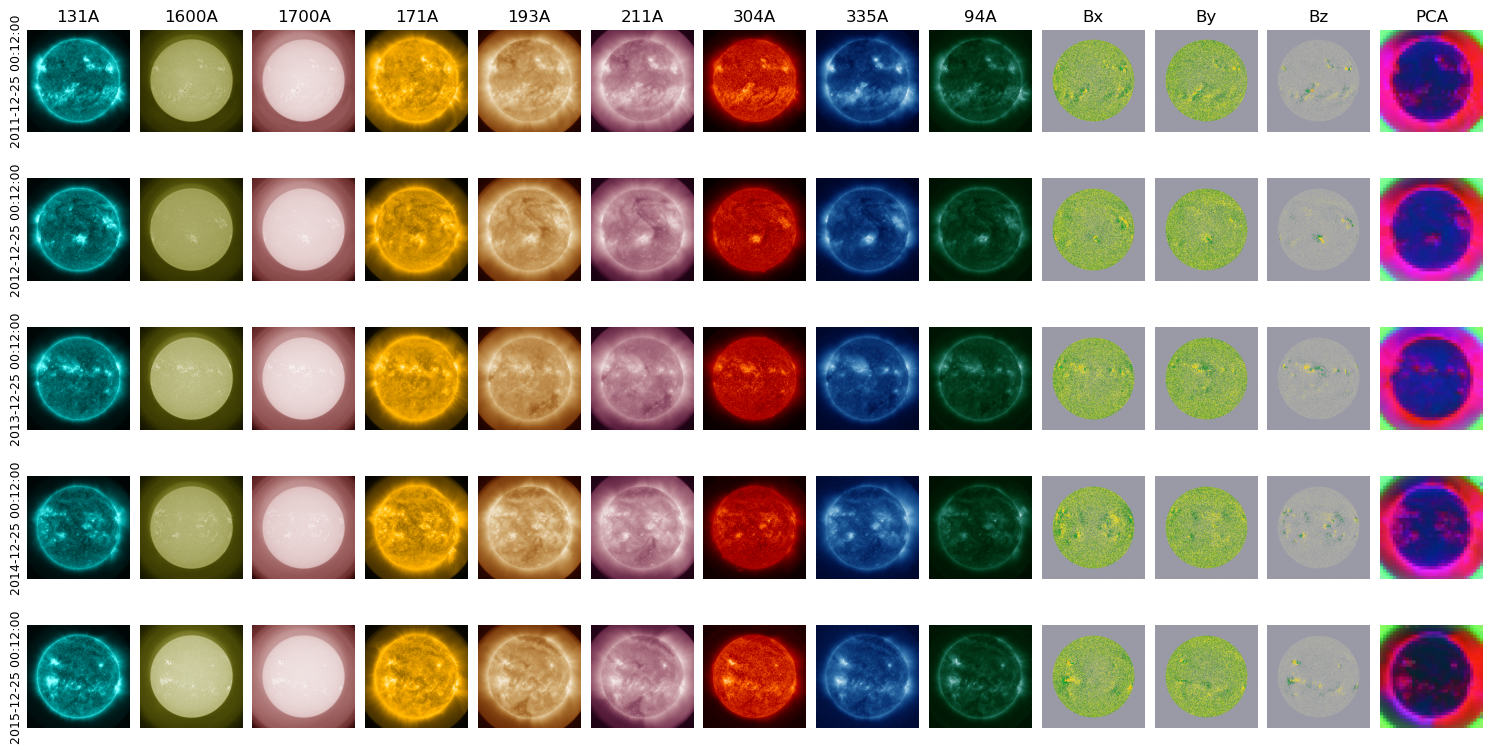

In [60]:
num_images = x_set.shape[0]
fig, axes = plt.subplots(num_images, 13, figsize=(15, 8), squeeze=False)
norm = TwoSlopeNorm(vmin=-4000, vcenter=0, vmax=4000)

for ax in axes.flat:
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)


for i in range(num_images):
    for i_col, ch_name in enumerate(chan_types):
        if i == 0:
            axes[i, i_col].set_title(f"{ch_name}", fontsize=12)
            axes[i, 12].set_title(f"PCA", fontsize=12)

        axes[i, i_col].imshow(x_set[i, i_col, 0, :, :].to("cpu").numpy(), cmap=cms[i_col], norm=norm if (i_col>=9 and i_col<=11) else None)
        axes[i, i_col].axis('off')

    axes[i, 12].imshow(pca_results[i], cmap="binary")
    axes[i, 12].axis('off')

for row_idx in range(num_images):
    axes[row_idx][0].text(
        -0.1, 0.5,              # Negative x moves it to the left
        f"{ts[row_idx]}", 
        ha='center', 
        va='center', 
        fontsize=9, 
        rotation=90,
        transform=axes[row_idx][0].transAxes # Ensures coordinates are relative to the subplot
    )

# Apply tight_layout first to handle outer margins and label fitting
plt.tight_layout()

# Then add the specific spacing you want between images
# wspace=0.1 means the gap is 10% of the subplot width
# hspace=0.1 means the gap is 10% of the subplot height
plt.subplots_adjust(wspace=0.1, hspace=0.01) 
plt.savefig("pca_analysis_ALL.pdf", dpi=300, bbox_inches="tight")
# plt.show()